# import library

In [1]:
import pandas as pd
pd.set_option('display.expand_frame_repr', False)
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split , cross_val_score,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
df=pd.read_csv(r"../data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# EDA

target
1    165
0    138
Name: count, dtype: int64


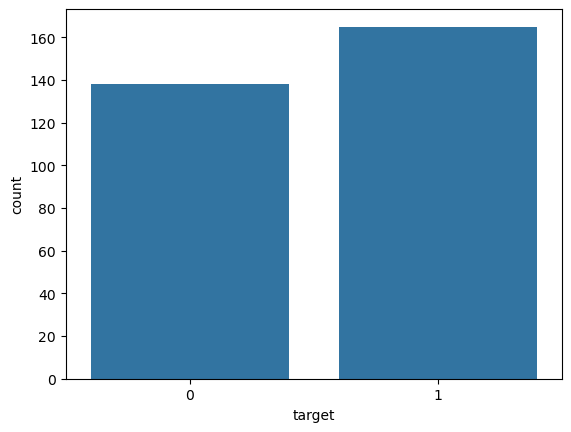

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


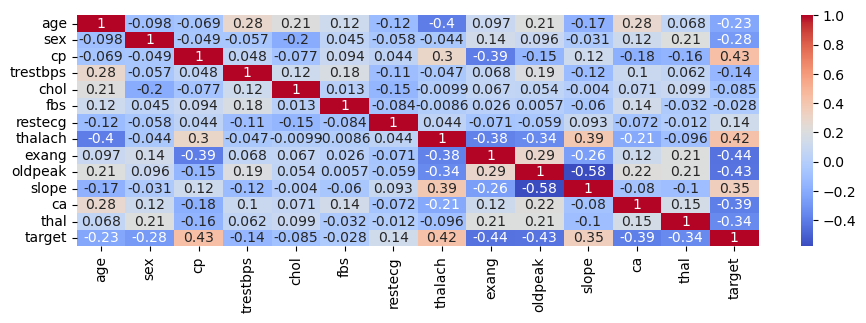

In [3]:
print(df['target'].value_counts())

sns.countplot(x=df['target'])
plt.show()


print(df.isnull().sum())


plt.figure(figsize=(11,3))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

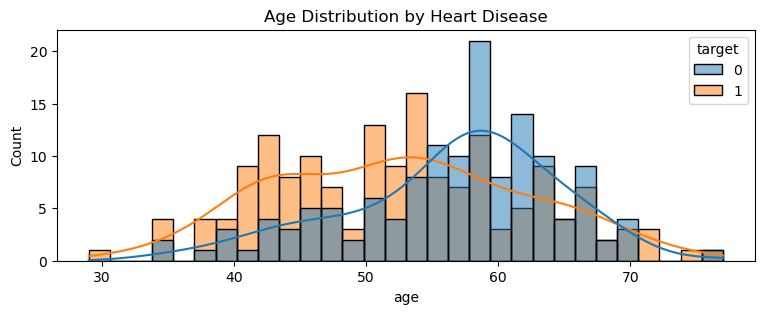

In [4]:
plt.figure(figsize=(9,3))
sns.histplot( x=df['age'], hue=df['target'], kde=True, bins=30)
plt.title('Age Distribution by Heart Disease')
plt.show()

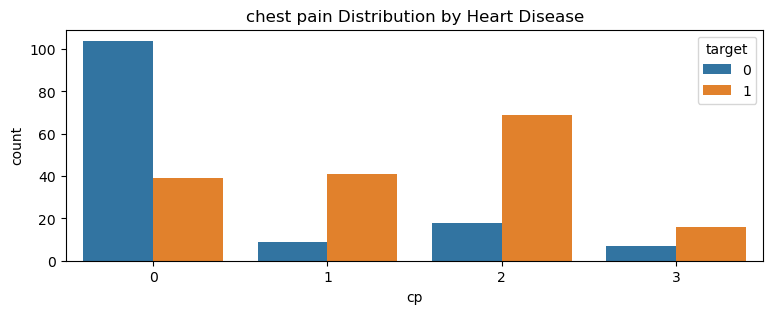

In [5]:
plt.figure(figsize=(9,3))
sns.countplot( x=df['cp'], hue=df['target'])
plt.title('chest pain Distribution by Heart Disease')
plt.show()

# Feature Engineering

In [6]:
x=df.drop(['target'],axis=1)
y=df['target']
print(x.head())
print(y.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal
0   63    1   3       145   233    1        0      150      0      2.3      0   0     1
1   37    1   2       130   250    0        1      187      0      3.5      0   0     2
2   41    0   1       130   204    0        0      172      0      1.4      2   0     2
3   56    1   1       120   236    0        1      178      0      0.8      2   0     2
4   57    0   0       120   354    0        1      163      1      0.6      2   0     2
0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64


In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

# Model training

**MODEL 1-LOGISTIC REGRESSION**

In [8]:
model1=LogisticRegression(random_state=42)
model1.fit(x_train,y_train)
lr_pred=model1.predict(x_test)
print("model training accuracy",accuracy_score(y_train,model1.predict(x_train)))
print("model test accuracy",accuracy_score(y_test,lr_pred))

model training accuracy 0.8636363636363636
model test accuracy 0.8524590163934426


**MODEL 2- RANDOM FOREST**

In [9]:
model2=RandomForestClassifier(random_state=42,n_estimators=100,max_depth=2)
model2.fit(x_train,y_train)

rf_pred=model2.predict(x_test)
print("model training accuracy",accuracy_score(y_train,model2.predict(x_train)))
print("model test accuracy",accuracy_score(y_test,rf_pred))


model training accuracy 0.859504132231405
model test accuracy 0.8688524590163934


**MODEL 3 - XG BOOST**

In [10]:

model3=XGBClassifier(random_state=42,max_depth=1, n_estimators=25, learning_rate=0.1)
model3.fit(x_train,y_train)

xgb_pred=model3.predict(x_test)
print("model training accuracy",accuracy_score(y_train,model3.predict(x_train)))
print("model test accuracy",accuracy_score(y_test,xgb_pred))

model training accuracy 0.8471074380165289
model test accuracy 0.8524590163934426


**GRID SEARCH AND FINE TUNE**

In [11]:
parameters1={
    'max_depth': [1,2,3, 4, 5],
    'n_estimators': [10,25,50, 100, 200],
}
parameters2={
    'max_depth': [1,2,3, 4, 5],
    'n_estimators': [10,25,50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2,0.3,0.4]
}


grid1 = GridSearchCV(model2, parameters1, cv=5, scoring='accuracy')
grid2 = GridSearchCV(model3, parameters2, cv=5, scoring='accuracy')
grid1.fit(x_train, y_train)
grid2.fit(x_train, y_train)

print("Best params:", grid1.best_params_)
print("Best score:", grid1.best_score_)
print("Best params:", grid2.best_params_)
print("Best score:", grid2.best_score_)

Best params: {'max_depth': 2, 'n_estimators': 100}
Best score: 0.8306122448979592
Best params: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 25}
Best score: 0.8266156462585034


**COMPARE**

In [12]:
data={
    'Logistic_Regression':round(accuracy_score(y_test,lr_pred)*100,2),
    "xgboost":round(accuracy_score(y_test,xgb_pred)*100,2),
    "random_forest":round(accuracy_score(y_test,rf_pred)*100,2)
}

result=pd.DataFrame([data])
print(result)

   Logistic_Regression  xgboost  random_forest
0                85.25    85.25          86.89


**Evaluating best model->Random Forest**

In [13]:
cm=confusion_matrix(y_test,rf_pred)
print(cm)
print("precision-",round(precision_score(y_test,rf_pred)*100,0),"%")
print("recall-",round(recall_score(y_test,rf_pred)*100,0),"%")
print("f1 score-",round(f1_score(y_test,rf_pred)*100,0),"%")

[[24  5]
 [ 3 29]]
precision- 85.0 %
recall- 91.0 %
f1 score- 88.0 %


**SAVE MODEL**

In [14]:
joblib.dump(model2,"../model/random_forest.pkl")
joblib.dump(scaler,"../model/random_forest-scaler.pkl")

['../model/random_forest-scaler.pkl']